In [1]:
import os
import glob
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import re

ERROR! Session/line number was not unique in database. History logging moved to new session 2045


In [2]:
def D_JS(p1,p2,tol=1e-16):
    p1=p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [3]:
#Transform density
def transform(density,density_ref,transform_type):
    dens = density
    dref  = density_ref
    ttype = transform_type
    if ttype=='value':
        dtrans = density
    elif ttype=='sqrt':
        dtrans = np.sqrt(np.abs(density))
    elif ttype=='log':
        dtrans  = np.log(np.abs(density))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        dtrans = (dens-dval)/dsqrt
    else:
        raise RuntimeError('bad transform type')
    return dtrans


def inverse_transform(density_trans,density_ref,transform_type):
    dref   = density_ref
    ttype  = transform_type
    dtrans = density_trans
    if ttype=='value':
        density = dtrans
    elif ttype=='sqrt':
        density = dtrans**2
    elif ttype=='log':
        density = np.log(np.abs(dtrans))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        density = dval + dsqrt*dtrans
    else:
        raise RuntimeError('bad transform type')
    return density


In [4]:
dft_path ='/pscratch/sd/k/kberard/SCGSR/Data/vo2_1x1x1_opt/density_data/vmc_noJ/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]
ref_path ='/pscratch/sd/k/kberard/SCGSR/Data/vo2_1x1x1_opt/density_data/vmc_J2/density_tot_ref_mean.h5'
with h5py.File(ref_path, 'r') as file:
    ref_d = file['density'][:]

I0000 00:00:1773677699.079136  913408 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38479 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:82:00.0, compute capability: 8.0
I0000 00:00:1773677700.347497  914148 service.cc:152] XLA service 0x7f9810004ad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773677700.347536  914148 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-03-16 09:15:00.366267: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773677700.436957  914148 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1773677702.427791  914148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


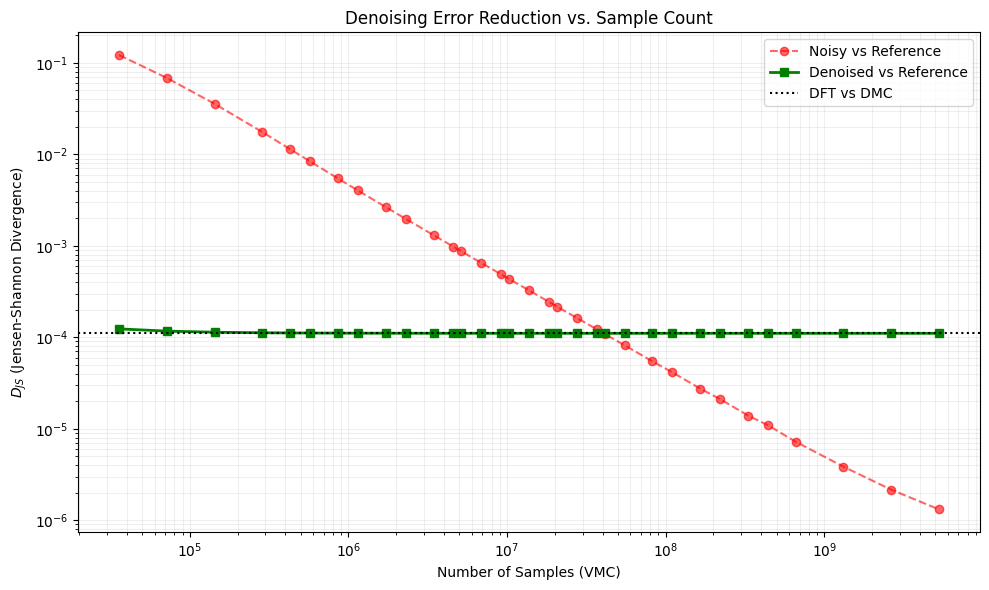

Data saved to vo2_jsd_data.csv


In [5]:
# --- Setup Directory Looping ---
model = tf.keras.models.load_model('residual_denoiser_40M_Blob_Fixed_trans.keras')
data_dir = '/pscratch/sd/k/kberard/SCGSR/Data/vo2_1x1x1_opt/density_data/vmc_J2/'
file_pattern = os.path.join(data_dir, "density_tot_vmc_mean_*.h5")
files = glob.glob(file_pattern)

results = []

# --- Processing Loop ---
for fpath in files:
    # Extract number of samples from filename using regex
    match = re.search(r'mean_(\d+)\.h5', os.path.basename(fpath))
    if not match: continue
    sample_count = int(match.group(1))
    
    with h5py.File(fpath, 'r') as f:
        test_d = np.array(f['density'])
    
    # 1. Transform & Predict
    input_reshaped = test_d[np.newaxis, ..., np.newaxis]
    dft_reshaped   = dft_d[np.newaxis, ..., np.newaxis]
    input_residual = transform(input_reshaped, dft_reshaped, 'residual_noise')
    
    pred_residual = model.predict(input_residual, verbose=0)
    
    # 2. Inverse Transform
    denoised_raw = inverse_transform(pred_residual, dft_reshaped, 'residual_noise')
    denoised = np.maximum(denoised_raw[0, ..., 0], 0.0)

    # 3. Store Metrics
    jsd_noisy = D_JS(test_d, ref_d)
    jsd_denoised = D_JS(denoised, ref_d)
    
    results.append((sample_count, jsd_noisy, jsd_denoised))

# --- Sorting & Plotting ---
# Sort results by sample count (x-axis)
results.sort(key=lambda x: x[0])
samples, noisy_jsds, denoised_jsds = zip(*results)

DFT_vs_DMC = D_JS(ref_d,dft_d)
plt.figure(figsize=(10, 6))
plt.plot(samples, noisy_jsds, 'r--o', label='Noisy vs Reference', alpha=0.6)
plt.plot(samples, denoised_jsds, 'g-s', label='Denoised vs Reference', linewidth=2)

plt.xscale('log') # Sample counts usually span orders of magnitude
plt.yscale('log') # JSD values often drop significantly
plt.axhline(DFT_vs_DMC, color="black", linestyle=":", label="DFT vs DMC")
plt.xlabel('Number of Samples (VMC)')
plt.ylabel('$D_{JS}$ (Jensen-Shannon Divergence)')
plt.title('Denoising Error Reduction vs. Sample Count')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

import pandas as pd

# Create a DataFrame with your data
data = {
    'Samples': samples,
    'Noisy_JSD': noisy_jsds,
    'Denoised_JSD': denoised_jsds
}
df = pd.DataFrame(data)

# Save to CSV
df.to_csv('Plot_Data/Vo2_Fixed_jsd_data_vmc_j2.csv', index=False)
print("Data saved to vo2_jsd_data.csv")


In [6]:
dft_path ='/pscratch/sd/k/kberard/SCGSR/Data/vo2_1x1x1_opt/density_data/vmc_noJ/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]
ref_path ='/pscratch/sd/k/kberard/SCGSR/Data/vo2_1x1x1_opt/density_data/dmc_J2/density_tot_ref_mean.h5'
with h5py.File(ref_path, 'r') as file:
    ref_d = file['density'][:]

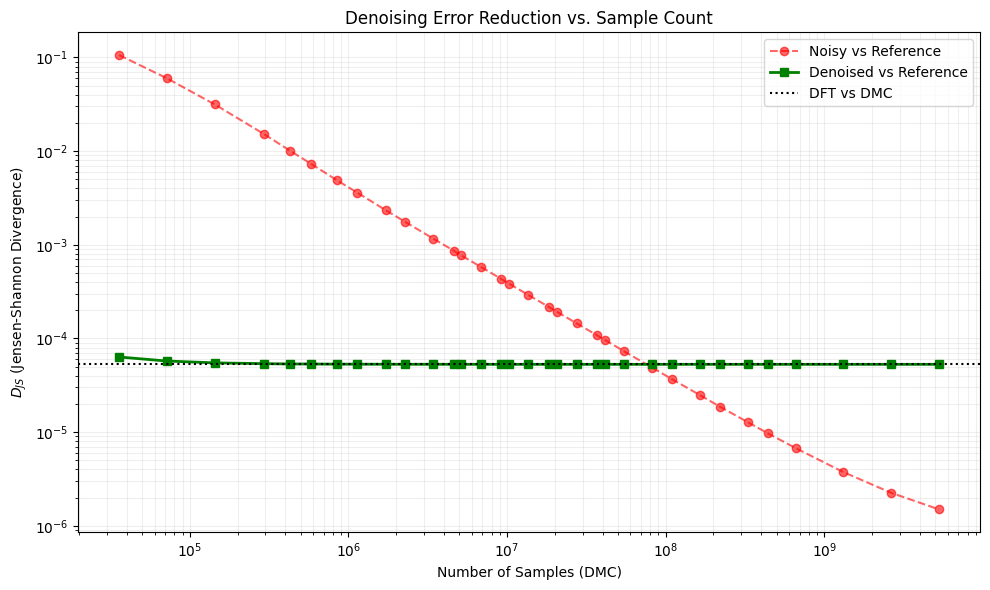

Data saved to vo2_jsd_data.csv


In [7]:
# --- Setup Directory Looping ---
model = tf.keras.models.load_model('residual_denoiser_40M_Blob_Fixed_trans.keras')
data_dir = '/pscratch/sd/k/kberard/SCGSR/Data/vo2_1x1x1_opt/density_data/dmc_J2/'
file_pattern = os.path.join(data_dir, "density_tot_dmc_mix_mean_*.h5")
files = glob.glob(file_pattern)

results = []

# --- Processing Loop ---
for fpath in files:
    # Extract number of samples from filename using regex
    match = re.search(r'mean_(\d+)\.h5', os.path.basename(fpath))
    if not match: continue
    sample_count = int(match.group(1))
    
    with h5py.File(fpath, 'r') as f:
        test_d = np.array(f['density'])
    
    # 1. Transform & Predict
    input_reshaped = test_d[np.newaxis, ..., np.newaxis]
    dft_reshaped   = dft_d[np.newaxis, ..., np.newaxis]
    input_residual = transform(input_reshaped, dft_reshaped, 'residual_noise')
    
    pred_residual = model.predict(input_residual, verbose=0)
    
    # 2. Inverse Transform
    denoised_raw = inverse_transform(pred_residual, dft_reshaped, 'residual_noise')
    denoised = np.maximum(denoised_raw[0, ..., 0], 0.0)

    # 3. Store Metrics
    jsd_noisy = D_JS(test_d, ref_d)
    jsd_denoised = D_JS(denoised, ref_d)
    
    results.append((sample_count, jsd_noisy, jsd_denoised))

# --- Sorting & Plotting ---
# Sort results by sample count (x-axis)
results.sort(key=lambda x: x[0])
samples, noisy_jsds, denoised_jsds = zip(*results)

DFT_vs_DMC = D_JS(ref_d,dft_d)
plt.figure(figsize=(10, 6))
plt.plot(samples, noisy_jsds, 'r--o', label='Noisy vs Reference', alpha=0.6)
plt.plot(samples, denoised_jsds, 'g-s', label='Denoised vs Reference', linewidth=2)

plt.xscale('log') # Sample counts usually span orders of magnitude
plt.yscale('log') # JSD values often drop significantly
plt.axhline(DFT_vs_DMC, color="black", linestyle=":", label="DFT vs DMC")
plt.xlabel('Number of Samples (DMC)')
plt.ylabel('$D_{JS}$ (Jensen-Shannon Divergence)')
plt.title('Denoising Error Reduction vs. Sample Count')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

import pandas as pd

# Create a DataFrame with your data
data = {
    'Samples': samples,
    'Noisy_JSD': noisy_jsds,
    'Denoised_JSD': denoised_jsds
}
df = pd.DataFrame(data)

# Save to CSV
df.to_csv('Plot_Data/Vo2_Fixed_jsd_data_dmc_j2.csv', index=False)
print("Data saved to vo2_jsd_data.csv")
